### Importing Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3

### Import_data

In [3]:
conn=sqlite3.connect("customer_churn.db")

In [4]:
sql_query=""" 
         SELECT name from 
         sqlite_master
         where type="table"
"""
tables=pd.read_sql(sql_query,conn)

### create data frame

In [6]:
for table_name in tables["name"]:
    df=pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]  = df
    print(f"created dataframe:df_{table_name}")        
conn.close()

created dataframe:df_db_customer
created dataframe:df_db_subscription
created dataframe:df_db_support


In [7]:
### print table names and column names 
conn=sqlite3.connect("customer_churn.db")
for table_name in tables["name"]:
    print(f"\n Table Name:{table_name}")
    # get columns information
    columns_query=f"PRAGMA table_info({table_name});"
    columns=pd.read_sql(columns_query,conn)
    print("columns:")
    print(columns["name"].tolist())
# close connection
conn.close()


 Table Name:db_customer
columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

 Table Name:db_subscription
columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

 Table Name:db_support
columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [8]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [10]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 2.5+ KB


In [11]:
# change name col
#  drop colums pincode and interest 
# cchange data dob
# fix missimg value countries
# data standardization

In [12]:
# changing name
df_db_customer.rename(columns={"name":"customer_name"},inplace=True)
df_db_customer.head(2)

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None


In [13]:
# drop colums
df_db_customer.drop(columns=["interests","pincode"],inplace=True)
df_db_customer.tail(2)

,customerid,customer_name,country,state,gender,dob
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00


In [16]:
# change datatype
df_db_customer["dob"]=pd.to_datetime(df_db_customer["dob"],)
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.8 KB


In [18]:
# data standardization
#df_db_customer["gender"].unique()
df_db_customer["gender"]=df_db_customer["gender"].replace({"Men":"Male","Women":"Female"})
df_db_customer["gender"].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [22]:
# dealing with null values 
df_db_customer["country"].isna()
df_db_customer[["country","state"]]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,NaN,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,NaN,Kathmandu
9,Nepal,Kathmandu


In [27]:
# country and state : unique value pair 
state_country_mapping=df_db_customer.dropna(subset=["country"]).set_index("state")["country"].to_dict()
df_db_customer["country"]=df_db_customer["country"].fillna(df_db_customer["state"].map(state_country_mapping))
df_db_customer[df_db_customer["country"].isna()]

,customerid,customer_name,country,state,gender,dob


In [29]:
df_db_subscription
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 3.1 KB


In [30]:
date_col=["subscription_start_date","renewal_date","cancellation_date"]
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 2.7 KB


In [31]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,NaN
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,NaN


In [32]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 895.0+ bytes


In [33]:
df_db_support.drop(columns=["col_1","comment"],inplace=True)
df_db_support.head()

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28 00:00:00,N,60
1,0003-MKNFE,2024-08-28 00:00:00,Y,10
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20
3,0013-MHZWF,2025-03-18 00:00:00,N,90
4,0013-SMEOE,2024-11-01 00:00:00,N,30


### Feature engineering

In [34]:
# creating a new column using existing table 
df_db_subscription.head(3)
df_db_subscription["churn_flag"]=np.where(df_db_subscription["cancellation_date"].notna(),1,0)
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [36]:
df_db_subscription.shape

(21, 12)

In [38]:
df_db_subscription["customerid"].nunique()

21

In [39]:
df_db_customer["customerid"].nunique()

21

In [40]:
df_db_support["customerid"].nunique()

7

In [41]:
df_db_support["customerid"].size

9

In [43]:
df_db_support["complaint_count"]=df_db_support.groupby("customerid")["customerid"].transform("count")
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28 00:00:00,N,60,2
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,2
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,1
3,0013-MHZWF,2025-03-18 00:00:00,N,90,1
4,0013-SMEOE,2024-11-01 00:00:00,N,30,1
5,0017-IUDMW,2024-04-10 00:00:00,Y,25,1
6,0019-EFAEP,2024-09-27 00:00:00,Y,30,1
7,0022-TCJCI,2024-09-13 00:00:00,Y,10,2
8,0022-TCJCI,2024-09-14 00:00:00,N,90,2


In [44]:
df_db_support=df_db_support.sort_values("complaint_date").drop_duplicates("customerid",keep="last")

In [46]:
df_db_support["customerid"].nunique()

7

In [47]:
df_db_support["customerid"].size

7

In [76]:
df=(df_db_subscription
               .merge(df_db_customer,on ="customerid",how="left")
               .merge(df_db_support,on ="customerid",how="left"))

df_db_subscription.shape
df.shape



(21, 21)

In [77]:
df

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaN,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28 00:00:00,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaN,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaN,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20 00:00:00,Y,20.0,1.0
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaT,NaN,17.99,720,...,0,durga,India,Delhi,Female,1988-12-10,2025-03-18 00:00:00,N,90.0,1.0
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,...,1,mina,India,Meghalaya,Female,1976-09-21,2024-11-01 00:00:00,N,30.0,1.0
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaT,NaN,22.99,1840,...,0,madan,India,Rajasthan,Male,1999-03-14,NaN,NaN,NaN,NaN
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,NaT,NaN,13.99,240,...,0,maya,Nepal,Kathmandu,Female,1985-07-07,NaN,NaN,NaN,NaN
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,NaT,NaN,6.99,335,...,0,arjun,Nepal,Kathmandu,Male,1993-10-29,NaN,NaN,NaN,NaN


### Data Analysis

In [49]:
df.to_csv("customer_churm.csv",index=False)

In [50]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [51]:
#churn rate 
churn_rate=df["churn_flag"].mean()*100
print("churn_rate",round(churn_rate,2),"%")

churn_rate 28.57 %


In [52]:
# retention rate
retention_rate =100-churn_rate
print("churn_rate",round(retention_rate,2),"%")

churn_rate 71.43 %


In [53]:
# churn by plan type 
churn_by_plan=df.groupby("plan_type")["churn_flag"].mean().mul(100).round(2).reset_index(name="churn_rate")
print(churn_by_plan)

  plan_type  churn_rate
0     Basic       60.00
1   Premium       14.29
2  Standard       22.22


In [54]:
# churn by state
churn_by_state=df.groupby("state")["churn_flag"].mean().round(2).reset_index(name="churn_by_state")
print(churn_by_state)

           state  churn_by_state
0          Delhi            0.25
1      Karnataka            1.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya            0.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana            0.50
8  Uttar Pradesh            0.00


### ARPU= Average Revenue Per user

In [55]:
arpu=df["monthly_charges"].mean().round(2)
print("arpu",arpu)

arpu 18.85


In [56]:
# average customer tenure
today=pd.Timestamp.today()
print(today)
df["tenure_days"]=np.where(
    df["cancellation_date"].notna(),
   (df["cancellation_date"]-df["subscription_start_date"]).dt.days,
   (today -df["subscription_start_date"]).dt.days
)
df.head(3)
avg_tenure_days=df["tenure_days"].mean().round(0)
print("avg_tenure_days",avg_tenure_days)

2026-09-15 21:19:47.871500
avg_tenure_days 1539.0


In [57]:
# revenue lost by churn user 
revenue_risk=df.loc[df["churn_flag"]==1,"monthly_charges"].sum()
print("revenue risk",revenue_risk)

revenue risk 73.94


In [58]:
# escalation rate 
esclation_rate=(df["escalations"]=="Y").mean()*100
print("esclation_rate",round(esclation_rate,2))


esclation_rate 19.05


In [59]:
# average customer per user 
avg_complaint=df["complaint_count"].sum()/df["customerid"].nunique()
print("average_count",round(avg_complaint,2))

average_count 0.43


### Visulaization

In [71]:
df_visual=df.copy()


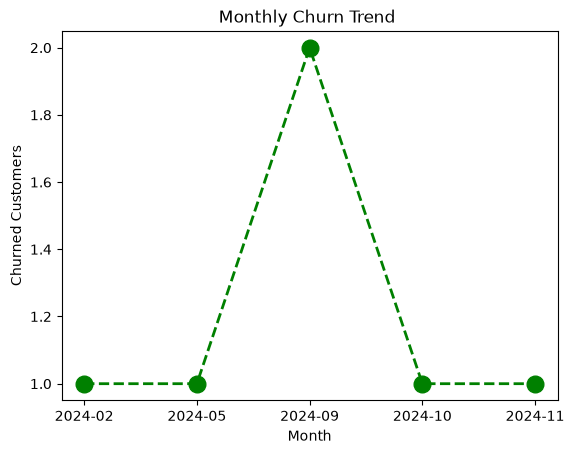

In [61]:
#  Monthly Churn Trend
df_visual["cancellation_month"]=df_visual["cancellation_date"].dt.to_period("M")
churn_trend=df_visual[df_visual["churn_flag"]==1].groupby("cancellation_month").size()
plt.plot(churn_trend.index.astype('str'),churn_trend.values,color="green",marker="o",linestyle="dashed",linewidth=2,markersize=12)
plt.title("Monthly Churn Trend ")
plt.xlabel("Month")
plt.ylabel("Churned Customers")
plt.show()

Text(0.5, 1.0, 'churn by Plan type')

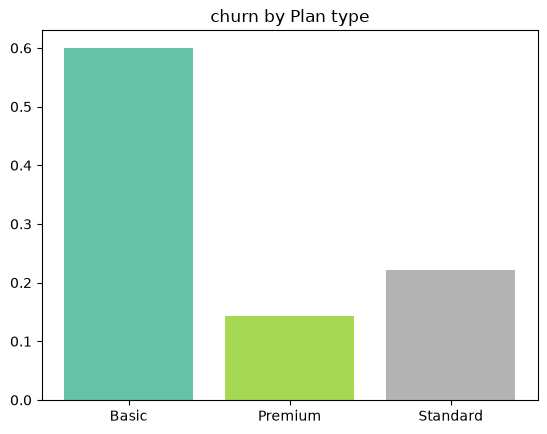

In [62]:
churn_plan=df_visual.groupby("plan_type")["churn_flag"].mean()
#colors=["green","purple","blue"]
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title("churn by Plan type")

Text(0.5, 1.0, 'churn by States')

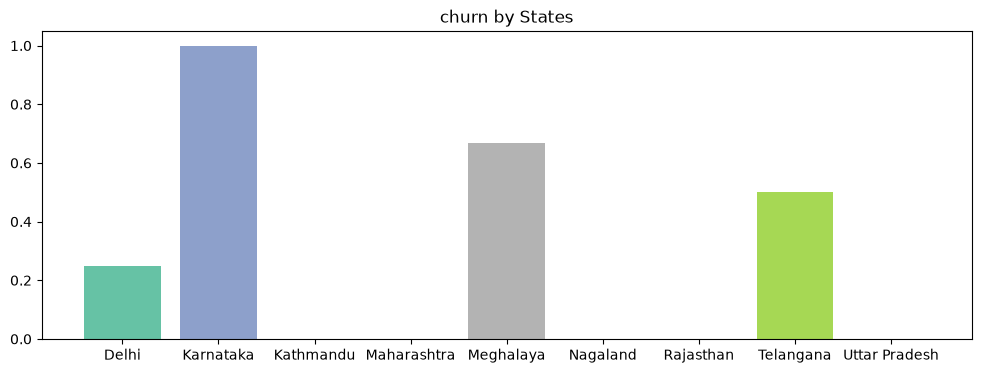

In [63]:
# churn by states 
churn_plan=df_visual.groupby("state")["churn_flag"].mean()
plt.figure(figsize=(12,4))
colors=plt.cm.Set2(np.linspace(0,1,len("state")))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.title("churn by States")

### Visualization Using Seaborn

In [110]:
# Encoding convert str to numeric so that we can find correlation between them
#df["endoded"]
df_encoded=df_visual[["plan_type","contract_type","churn_score","churn_flag",]]
order_maping={
    "plan_type":["Basic","Standard","Premium"],
    "contract_type":["Monthly","Annual"],
    "churn_flag":[0,1]
}
for col,categories in order_maping.items():
    df_encoded[col]=pd.Categorical(df_encoded[col].astype("category"),categories=categories,ordered=True).codes


In [111]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')

<Axes: >

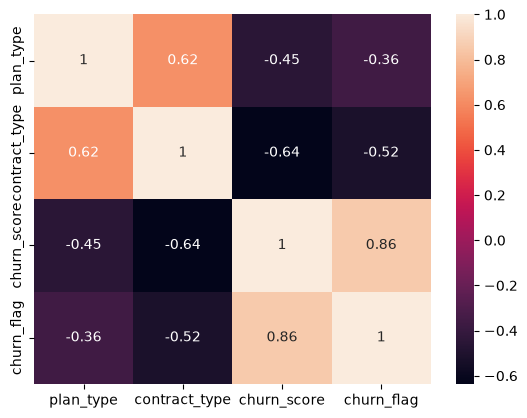

In [112]:
# Heat Map(correlation Matrix)

sns.heatmap(df_encoded.corr(),annot=True)


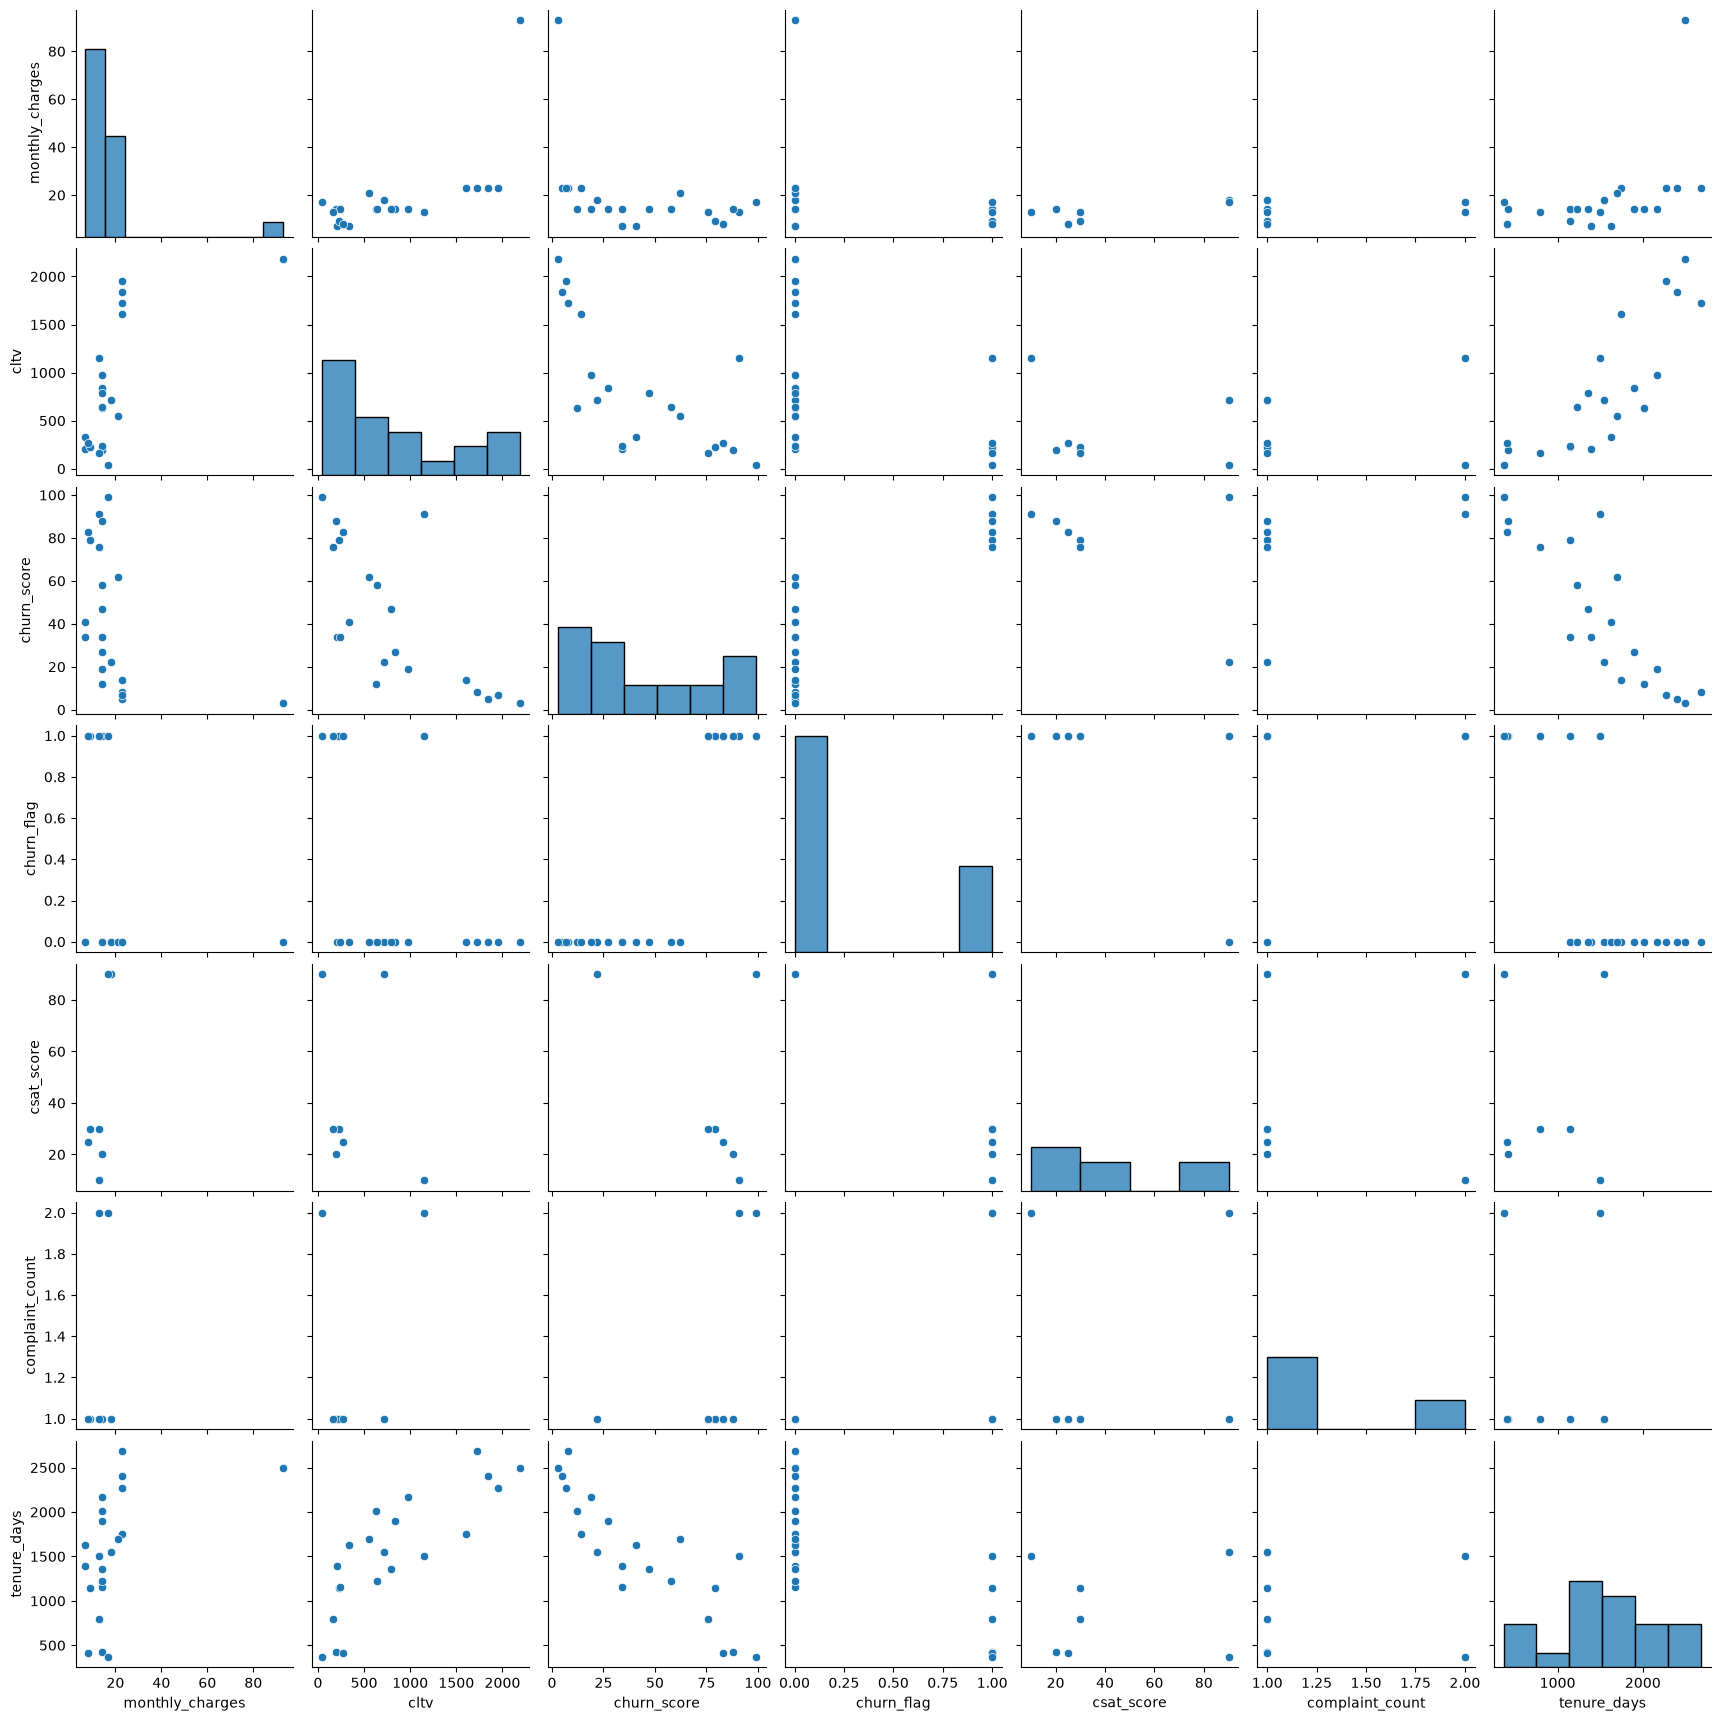

In [115]:
sns.pairplot(df_visual)